In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# K-Means 평균 군집

## 데이터 불러오기 및 Scaling

scaling 된 데이터는 다른 KMeans 외 다른 모형에도 사용됨

In [4]:
from sklearn.datasets import load_iris
from sklearn import preprocessing

# Load the iris dataset
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Scaling
scaler = preprocessing.StandardScaler()
scaled_data = scaler.fit_transform(iris_df)

## 모형의 적합

In [10]:
from sklearn.cluster import KMeans

# Perform KMeans clustering
km = KMeans(n_clusters = 3, random_state = 42)
km.fit(scaled_data)
labels = km.labels_
centers = km.cluster_centers_

## 결과

In [11]:
# Create a DataFrame with the clustering results
kmeans_df = pd.DataFrame(scaled_data, columns=iris.feature_names)
kmeans_df['cluster'] = labels
kmeans_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,-0.900681,1.019004,-1.340227,-1.315444,1
1,-1.143017,-0.131979,-1.340227,-1.315444,2
2,-1.385353,0.328414,-1.397064,-1.315444,2
3,-1.506521,0.098217,-1.283389,-1.315444,2
4,-1.021849,1.249201,-1.340227,-1.315444,1


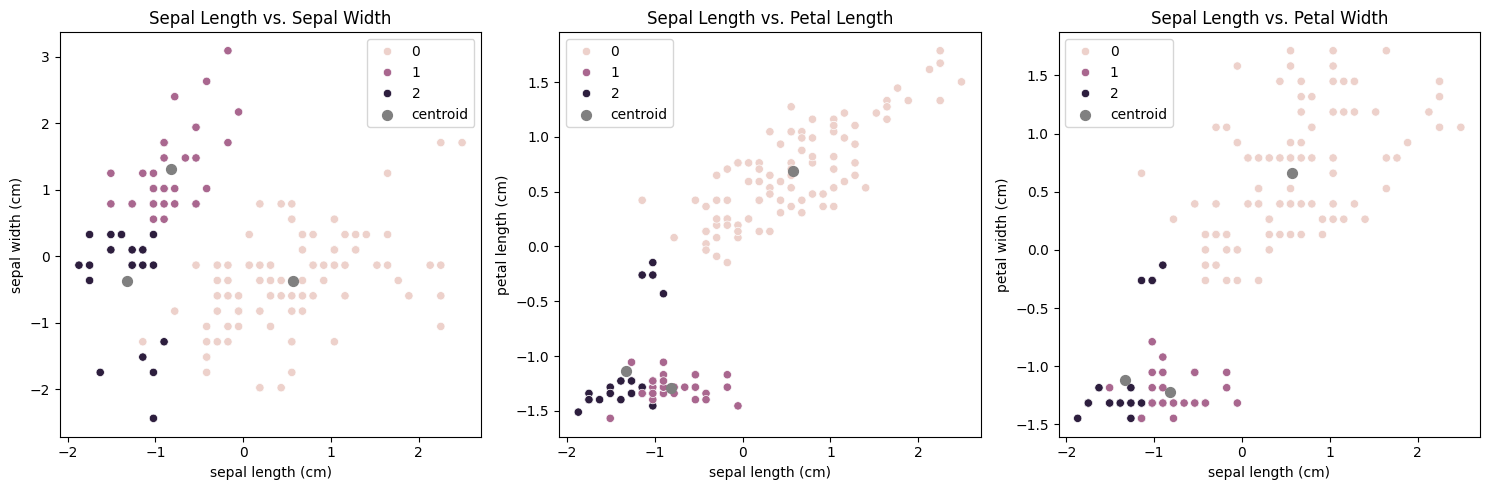

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (sepal length, sepal width)
sns.scatterplot(ax=axes[0], x='sepal length (cm)', y='sepal width (cm)', hue='cluster', data=kmeans_df)
axes[0].scatter(centers[:, 0], centers[:, 1], marker='.', s=200, c='gray', label='centroid')
axes[0].set_title('Sepal Length vs. Sepal Width')
axes[0].legend()


# (sepal length, petal length)
sns.scatterplot(ax=axes[1], x='sepal length (cm)', y='petal length (cm)', hue='cluster', data=kmeans_df)
axes[1].scatter(centers[:, 0], centers[:, 2], marker='.', s=200, c='gray', label='centroid')
axes[1].set_title('Sepal Length vs. Petal Length')
axes[1].legend()


# (sepal length, petal width)
sns.scatterplot(ax=axes[2], x='sepal length (cm)', y='petal width (cm)', hue='cluster', data=kmeans_df)
axes[2].scatter(centers[:, 0], centers[:, 3], marker='.', s=200, c='gray', label='centroid')
axes[2].set_title('Sepal Length vs. Petal Width')
axes[2].legend()

plt.tight_layout()
plt.show()

## 최적의 군집 갯수

In [24]:
wss = []
for k in range(1, 11):
    kms = KMeans(n_clusters = k, random_state = 42)
    kms.fit(scaled_data)
    wss.append(kms.inertia_)

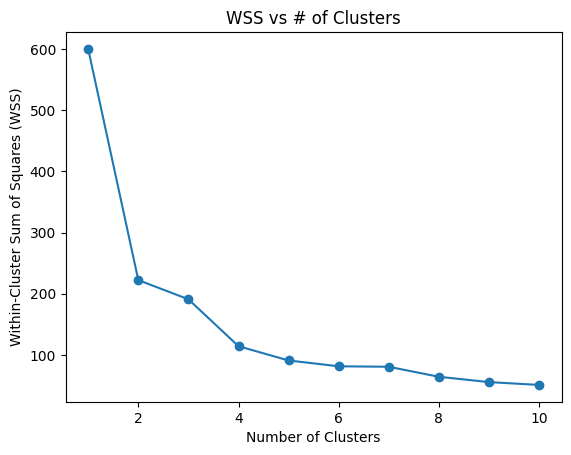

In [30]:
plt.plot(range(1, 11), wss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares (WSS)")
plt.title("WSS vs # of Clusters")
plt.show()


# 계층적 군집분석 (Hierachial Clustering)

## 모형의 적합

In [31]:
from sklearn.cluster import AgglomerativeClustering

hc_model = AgglomerativeClustering(n_clusters=3)
labels = hc_model.fit_predict(scaled_data)
hierarchical_df = pd.DataFrame(scaled_data, columns = iris.feature_names)
hierarchical_df['cluster'] = labels
hierarchical_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,-0.900681,1.019004,-1.340227,-1.315444,1
1,-1.143017,-0.131979,-1.340227,-1.315444,1
2,-1.385353,0.328414,-1.397064,-1.315444,1
3,-1.506521,0.098217,-1.283389,-1.315444,1
4,-1.021849,1.249201,-1.340227,-1.315444,1


## 덴드로그램

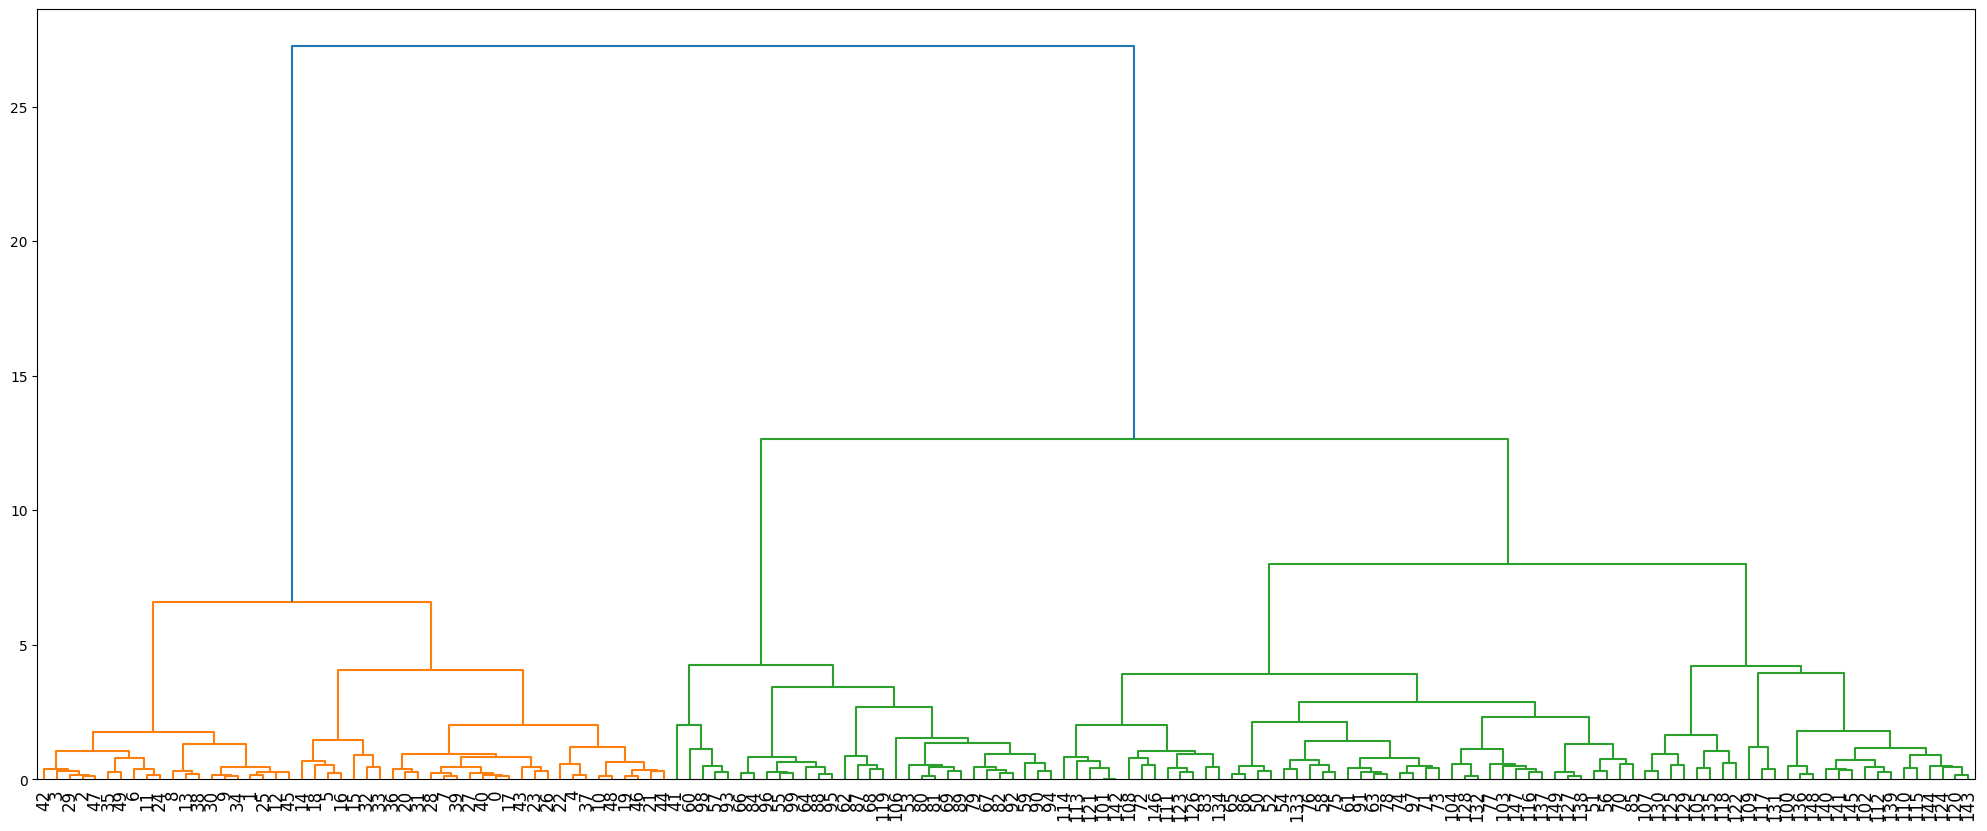

In [32]:
# Dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
linked = linkage(scaled_data, method = 'ward')
plt.figure(figsize = (25, 10))
dendrogram(linked, leaf_rotation=90, leaf_font_size=12)
plt.show()

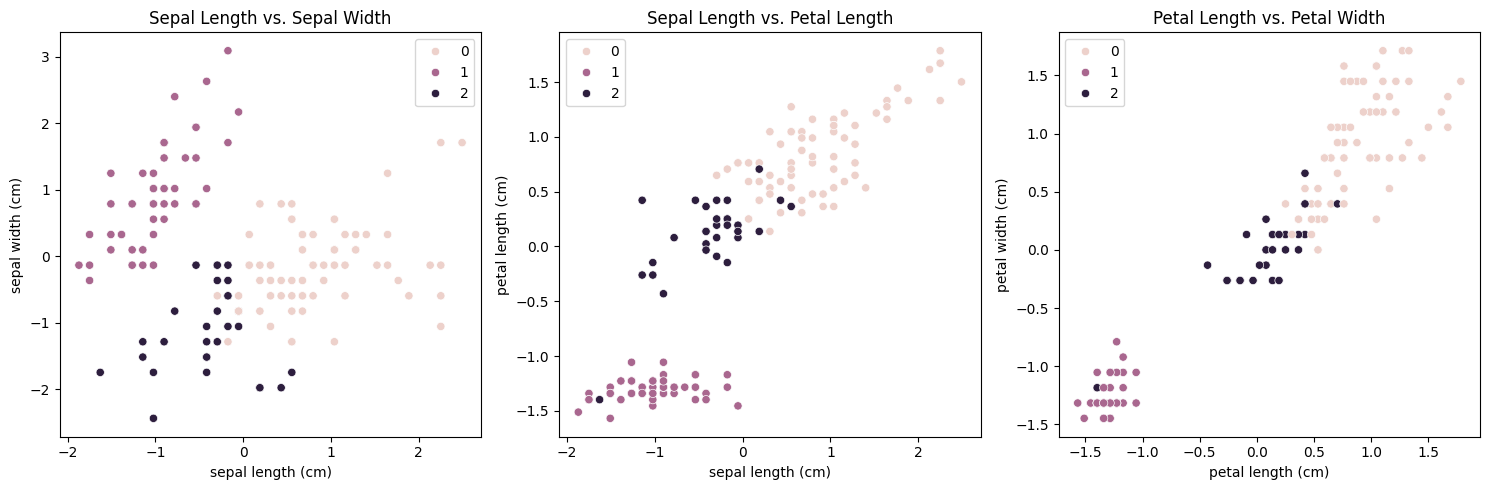

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (sepal length, sepal width)
sns.scatterplot(ax=axes[0], x='sepal length (cm)', y='sepal width (cm)', hue='cluster', data=hierarchical_df)
axes[0].set_title('Sepal Length vs. Sepal Width')
axes[0].legend()

# (sepal length, petal length)
sns.scatterplot(ax=axes[1], x='sepal length (cm)', y='petal length (cm)', hue='cluster', data=hierarchical_df)
axes[1].set_title('Sepal Length vs. Petal Length')
axes[1].legend()

# (petal length, petal width)
sns.scatterplot(ax=axes[2], x='petal length (cm)', y='petal width (cm)', hue='cluster', data=hierarchical_df)
axes[2].set_title('Petal Length vs. Petal Width')
axes[2].legend()

plt.tight_layout()
plt.show()


# DBSCAN

In [40]:
from sklearn.cluster import DBSCAN

db_model = DBSCAN(eps = 0.5,min_samples = 5)
labels = db_model.fit_predict(scaled_data)
dbscan_df = pd.DataFrame(scaled_data, columns = iris.feature_names)
dbscan_df['cluster'] = labels
dbscan_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,-0.900681,1.019004,-1.340227,-1.315444,0
1,-1.143017,-0.131979,-1.340227,-1.315444,0
2,-1.385353,0.328414,-1.397064,-1.315444,0
3,-1.506521,0.098217,-1.283389,-1.315444,0
4,-1.021849,1.249201,-1.340227,-1.315444,0


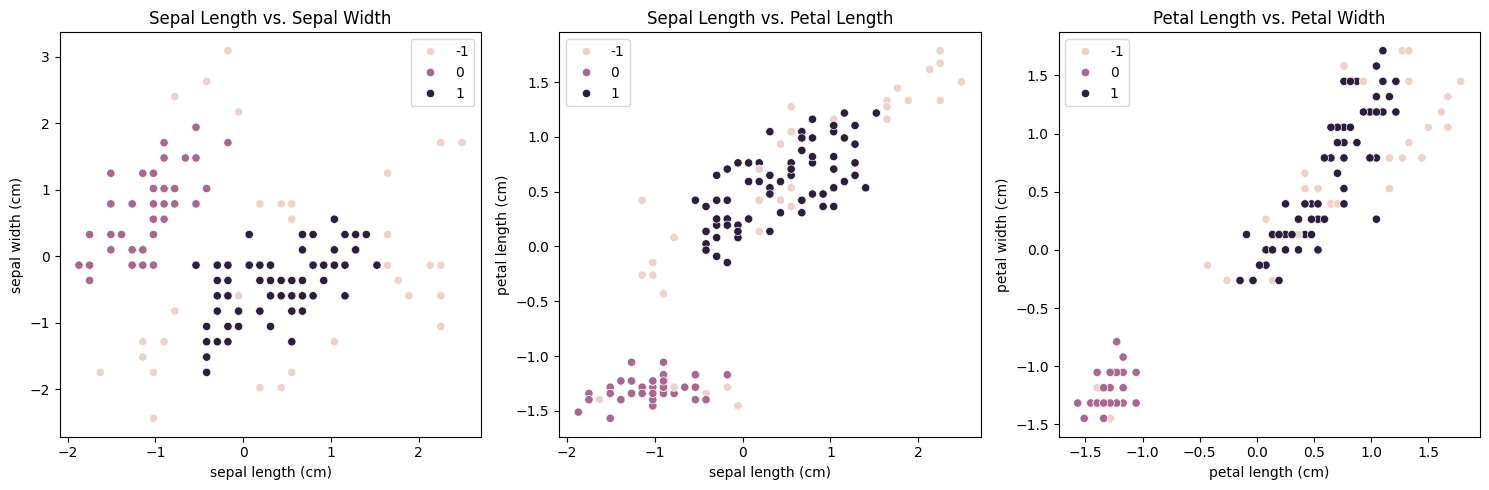

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (sepal length, sepal width)
sns.scatterplot(ax=axes[0], x='sepal length (cm)', y='sepal width (cm)', hue='cluster', data=dbscan_df)
axes[0].set_title('Sepal Length vs. Sepal Width')
axes[0].legend()

# (sepal length, petal length)
sns.scatterplot(ax=axes[1], x='sepal length (cm)', y='petal length (cm)', hue='cluster', data=dbscan_df)
axes[1].set_title('Sepal Length vs. Petal Length')
axes[1].legend()

# (petal length, petal width)
sns.scatterplot(ax=axes[2], x='petal length (cm)', y='petal width (cm)', hue='cluster', data=dbscan_df)
axes[2].set_title('Petal Length vs. Petal Width')
axes[2].legend()

plt.tight_layout()
plt.show()


# Gaussian Mixture Model

In [42]:
np.random.seed(1)
n = 1000
p = 0.4
mu1, sigma1 = [0,1]
mu2, sigma2 = [5,1]

z = np.random.binomial(1, p, n)
x1 = np.random.normal(mu1, sigma1, n)
x2 = np.random.normal(mu2, sigma2, n)
x = z * x1 + (1-z) * x2

<Axes: ylabel='Density'>

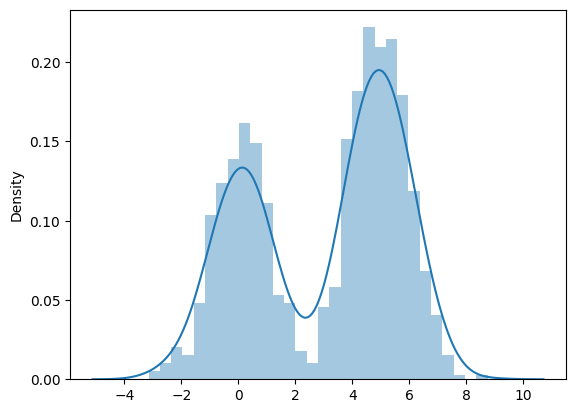

In [53]:
sns.distplot(x, bins = 30)

## 모형의 적합

In [54]:
from sklearn.mixture import GaussianMixture

gaussian = GaussianMixture(n_components = 3)
gaussian.fit(scaled_data)

GaussianMixture(n_components=3)

## 결과

In [55]:
labels = gaussian.predict(scaled_data)
gaussian_df = pd.DataFrame(scaled_data, columns=iris.feature_names)
gaussian_df['cluster'] = labels
gaussian_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,-0.900681,1.019004,-1.340227,-1.315444,1
1,-1.143017,-0.131979,-1.340227,-1.315444,1
2,-1.385353,0.328414,-1.397064,-1.315444,1
3,-1.506521,0.098217,-1.283389,-1.315444,1
4,-1.021849,1.249201,-1.340227,-1.315444,1


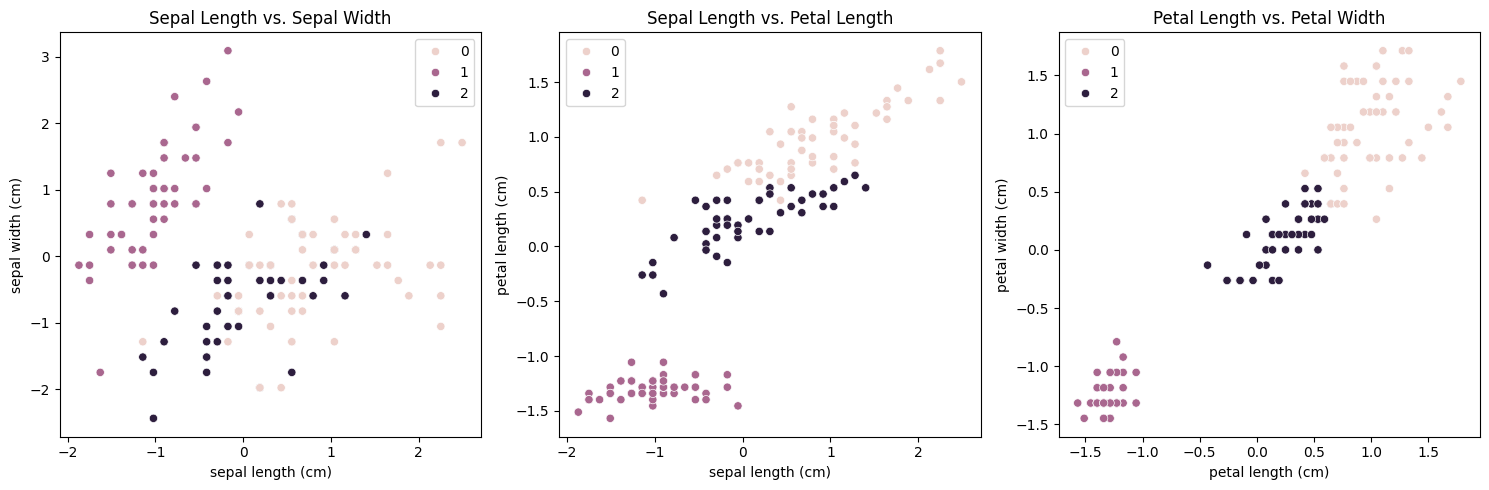

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (sepal length, sepal width)
sns.scatterplot(ax=axes[0], x='sepal length (cm)', y='sepal width (cm)', hue='cluster', data=gaussian_df)
axes[0].set_title('Sepal Length vs. Sepal Width')
axes[0].legend()

# (sepal length, petal length)
sns.scatterplot(ax=axes[1], x='sepal length (cm)', y='petal length (cm)', hue='cluster', data=gaussian_df)
axes[1].set_title('Sepal Length vs. Petal Length')
axes[1].legend()

# (petal length, petal width)
sns.scatterplot(ax=axes[2], x='petal length (cm)', y='petal width (cm)', hue='cluster', data=gaussian_df)
axes[2].set_title('Petal Length vs. Petal Width')
axes[2].legend()

plt.tight_layout()
plt.show()


## 최적의 군집갯수 결정 (BIC)

In [57]:
bic = []
for k in range(1, 11):
    gas = GaussianMixture(n_components = k)
    gas.fit(scaled_data)
    bic.append(gas.bic(scaled_data))

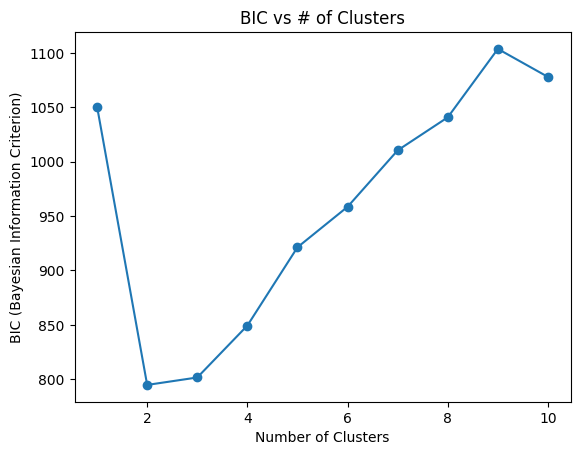

In [59]:
plt.plot(range(1, 11), bic, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("BIC (Bayesian Information Criterion)")
plt.title("BIC vs # of Clusters")
plt.show()
